In [1]:
# loading ccxt data
from MLTT.data_loading import ccxt_ohlcv
from MLTT.data_loading.interface import load_symbols
from MLTT import CapitalAllocator

import numpy as np

import matplotlib.pyplot as plt
import torch
from MLTT.data_loading.interface import check_linearity
from MLTT.validation import BucketWatcher
from MLTT import backtest_model

In [2]:
import nest_asyncio
nest_asyncio.apply()

In [3]:
symbols = load_symbols('symbols.txt')

Successfully loaded 115 symbols from file: symbols.txt


In [4]:
frames = ccxt_ohlcv('binance', symbols, '8h')
# Find the most recent date across all symbols
most_recent_date = max(frames[symbol].index.max() for symbol in symbols)

# Find minimum length across all symbols with most recent data
min_length = float('inf')
for symbol in symbols:
    sym_info = frames[symbol]
    if sym_info.index.max() == most_recent_date:
        min_length = min(min_length, len(sym_info))

# Initialize matrices with minimum length
prices_matrix = np.zeros((min_length, len(symbols)))
timestamps = np.zeros_like(prices_matrix)

# Populate matrices with data, excluding symbols with outdated data
equal_period_frames = []
for i, symbol in enumerate(symbols):
    sym_info = frames[symbol]
    if sym_info.index.max() == most_recent_date:
        # Take last min_length rows to align all series
        prices_matrix[:, i] = sym_info['close'][-min_length:]
        timestamp_sym = sym_info.index[-min_length:]
        timestamps[:, i] = timestamp_sym.values
        equal_period_frames.append(sym_info[-min_length:])

no_null_symbols = np.where(prices_matrix.sum(axis=0) != 0)[0]
prices_matrix = prices_matrix[:, no_null_symbols]
symbols = np.array(symbols)[no_null_symbols]
timestamps = timestamps[:, no_null_symbols]

In [5]:
if np.all(timestamps == timestamps[:, 0].reshape(-1, 1)):
    print("🟢All timestamps are the same")
else:
    print("🔴Timestamps are not the same")

🟢All timestamps are the same


In [6]:
is_ok = check_linearity(timestamps[:, 0], tolerance=0.01)
if is_ok:
    print("🟢Timestamps are linear")
else:
    print("🔴Timestamps are not linear")

🟢Timestamps are linear


In [7]:
ohlcv = torch.tensor(
    np.array([
        frame.values
        for frame in equal_period_frames
    ])
).transpose(0, 1)
ohlcv.shape

torch.Size([1000, 115, 5])

In [8]:
from MLTT.utils import change
from MLTT import to_weights_matrix

class CrossSectionalMR(CapitalAllocator):
    def __init__(self, lag_period: int = 1):
        self.lag_period = lag_period

    def predict(self, x: torch.Tensor) -> torch.Tensor:
        prices = x[:, :, 3]  # o, h, l, >C<, v - 3
        diff = change(prices)
        mkt_diff = diff.mean(dim=1)
        return to_weights_matrix(mkt_diff.unsqueeze(1) - diff)
    
    @property
    def min_observations(self) -> int:
        return self.lag_period

In [9]:
ohlc = ohlcv[:, :, :4]
volume = ohlcv[:, :, [4]]
log_ohlcv = torch.cat([
    torch.log(ohlc), 
    torch.log(volume + 1e-6)], 
dim=2)
log_ohlcv.shape

torch.Size([1000, 115, 5])

In [10]:
log_close = log_ohlcv[:, :, 3]
log_close.shape

torch.Size([1000, 115])

In [11]:
mr = CrossSectionalMR(100)
mr.predict(log_ohlcv).shape

torch.Size([1000, 115])

## Usual Backtest

In [12]:
res = backtest_model(mr, prices=log_close, prediction_info=log_ohlcv, commission=0.2 / 100)

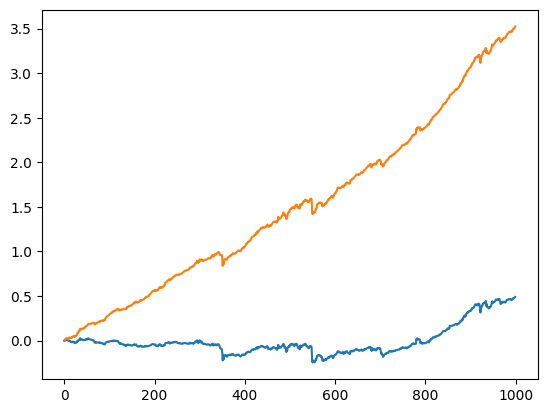

In [13]:
plt.plot(res.log_equity)
plt.plot(res.gross_equity)

## Bucket features

In [14]:
def adv(x: torch.Tensor) -> torch.Tensor:
    """
    Calculates the average daily volume for each asset on first half of data

    Args:
        x (torch.Tensor): Tensor of OHLCV data of shape (total_observations, n_assets, 5)

    Returns:
        torch.Tensor: Tensor of shape (n_assets,)
    """
    x = x[:len(x) // 2]

    log_volumes = x[:, :, 4]
    volumes = torch.exp(log_volumes)
    return volumes.mean(dim=0)

def beta(x: torch.Tensor) -> torch.Tensor:
    """
    Calculates the correlation between the asset and the market returns on first half of data

    Args:
        x (torch.Tensor): Tensor of OHLCV data of shape (total_observations, n_assets, 5)

    Returns:
        torch.Tensor: Tensor of shape (n_assets,)
    """
    x = x[:len(x) // 2]

    log_close = x[:, :, 3]
    log_returns = change(log_close)
    mkt_returns = log_returns.mean(dim=1)
    
    # Calculate covariance between asset returns and market returns
    demean_returns = log_returns - log_returns.mean(dim=0)
    demean_mkt = mkt_returns - mkt_returns.mean()
    
    cov = torch.einsum('ij,i->j', demean_returns, demean_mkt)
    var = torch.sum(demean_mkt ** 2)
    
    return cov / var

In [15]:
bw = BucketWatcher(log_close, log_ohlcv)
bw.make_buckets([adv, beta], 0.15)

(tensor([[False, False,  True, False, False,  True, False,  True, False, False,
          False, False, False, False, False, False, False, False, False, False,
           True, False, False, False, False, False, False,  True, False,  True,
          False, False, False, False, False, False, False, False, False,  True,
          False, False, False, False,  True, False, False, False, False,  True,
          False, False, False, False, False, False, False, False, False, False,
          False, False, False, False, False, False, False, False, False,  True,
          False, False, False, False, False, False, False, False, False, False,
           True, False,  True, False, False, False, False, False, False, False,
          False, False, False, False, False, False,  True, False, False, False,
           True, False, False,  True, False, False,  True,  True, False, False,
          False, False, False,  True, False],
         [False,  True, False, False, False, False, False, False, False, F

In [16]:
all_tests = bw.backtest_buckets(mr, mode="FILTER_OUTPUT", commission=0.2 / 100)
all_tests

{'commission': 0.002}
{'commission': 0.002}
{'commission': 0.002}
{'commission': 0.002}


{'top_0.15_adv': <MLTT.allocation.backtesting.BTResult at 0x7f1455c15f40>,
 'bottom_0.15_adv': <MLTT.allocation.backtesting.BTResult at 0x7f14547e2960>,
 'top_0.15_beta': <MLTT.allocation.backtesting.BTResult at 0x7f14547e1d90>,
 'bottom_0.15_beta': <MLTT.allocation.backtesting.BTResult at 0x7f14543ebd40>}

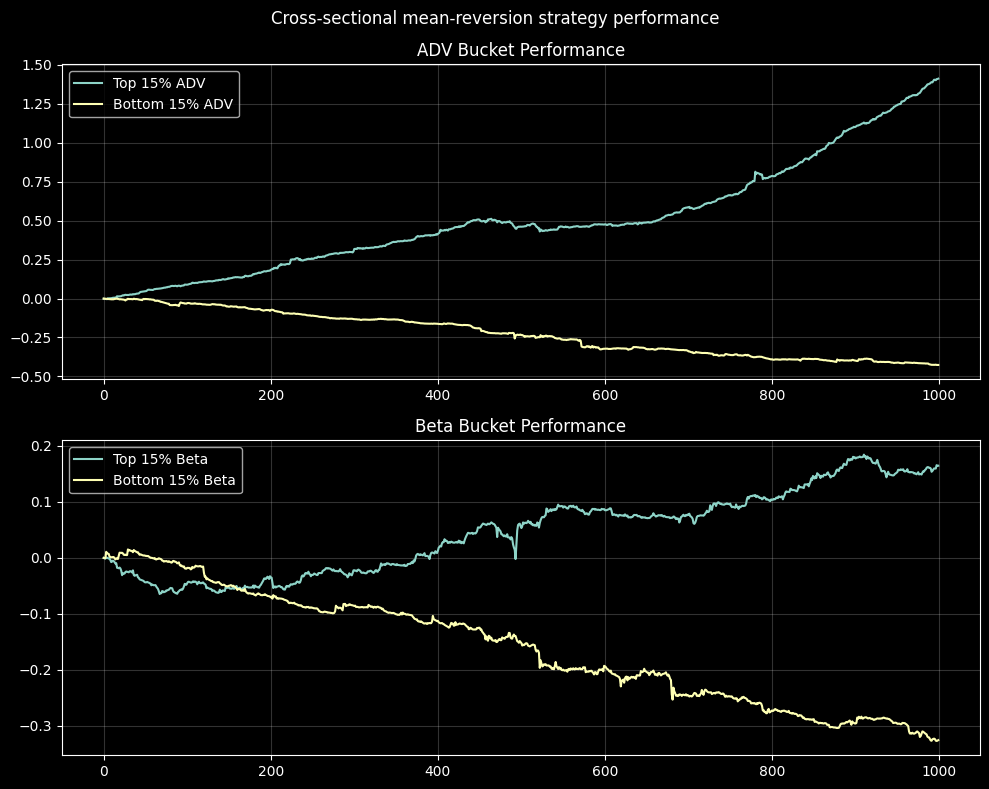

In [17]:
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

fig.suptitle('Cross-sectional mean-reversion strategy performance', color='white')
# Plot ADV buckets
ax1.plot(all_tests['top_0.15_adv'].log_equity, label='Top 15% ADV')
ax1.plot(all_tests['bottom_0.15_adv'].log_equity, label='Bottom 15% ADV')
ax1.set_title('ADV Bucket Performance', color='white')
ax1.legend()
ax1.grid(True, alpha=0.2)
ax1.set_facecolor('black')

# Plot Beta buckets 
ax2.plot(all_tests['top_0.15_beta'].log_equity, label='Top 15% Beta')
ax2.plot(all_tests['bottom_0.15_beta'].log_equity, label='Bottom 15% Beta')
ax2.set_title('Beta Bucket Performance', color='white')
ax2.legend()
ax2.grid(True, alpha=0.2)
ax2.set_facecolor('black')

fig.patch.set_facecolor('black')
plt.tight_layout()

# Leakage testing

In [ ]:
from MLTT.validation.leak_check import WeightConsistencyChecker

checker = WeightConsistencyChecker(
    prediction_info=log_ohlcv,
    window_size=mr.min_observations + 2,
    step=10,
    tolerance=1e-10
)
checker.check(mr)

✅ CONSISTENT WEIGHTS
Threshold: 1.0e-10
Total discrepancies: 0